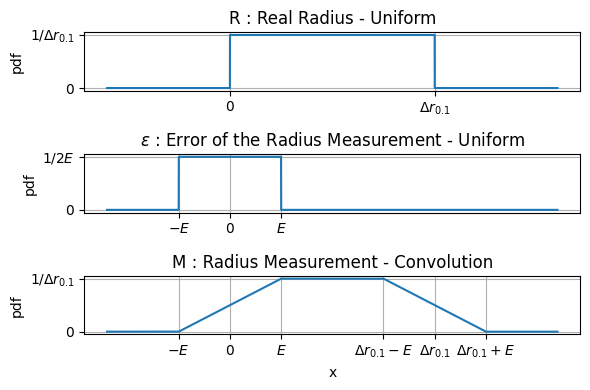

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters (normalized)
# ----------------------------
Delta = 1.0      # Δr (bin width)
E = 0.25         # so [-E, E] = [-1/4, 1/4]

dx = 1e-4

# Choose an x-range that fully contains both functions
xmin, xmax = -0.6, 1.6
x = np.arange(xmin, xmax + dx, dx)

# f1(x) = 1 on [0, Delta], else 0
f1 = np.where((x >= 0) & (x <= Delta), 1.0, 0.0)

# f2(x) = 1/2 on [-E, E], else 0  (as you requested)
amp2 = 0.5
f2 = np.where((x >= -E) & (x <= E), 1/(2*E), 0.0)

# ----------------------------
# Convolution (FULL) + correct x-axis for the result
# Discrete approximation of continuous convolution: conv * dx
# ----------------------------
conv_full = np.convolve(f1, f2, mode='full') * dx

# x-axis for full convolution:
# if x starts at xmin and has step dx, then (f1*f2) starts at 2*xmin
x_conv = np.arange(2*xmin, 2*xmax + dx, dx)

# (Optional) crop convolution to the same visible region as x for nicer plotting
mask = (x_conv >= xmin) & (x_conv <= xmax)
x_conv_plot = x_conv[mask]
conv_plot = conv_full[mask]

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=False)

axes[0].plot(x, f1)
axes[0].set_title(r"R : Real Radius - Uniform")
axes[0].set_ylabel("pdf")
axes[0].grid(True)

# Custom ticks/labels on convolution plot
ticks = [0, Delta]
tick_labels = [r"$0$", r"$\Delta r_{0.1}$"]
axes[0].set_xticks(ticks)
axes[0].set_xticklabels(tick_labels)
ticks = [0, 1/Delta]
tick_labels = [r"$0$", r"$1/\Delta r_{0.1}$"]
axes[0].set_yticks(ticks)
axes[0].set_yticklabels(tick_labels)

axes[1].plot(x, f2)
axes[1].set_title(r"$\varepsilon$ : Error of the Radius Measurement - Uniform")
axes[1].set_ylabel("pdf")
axes[1].grid(True)


# Custom ticks/labels on convolution plot
ticks = [-E, 0, E]
tick_labels = [r"$-E$", r"$0$", r"$E$"]
axes[1].set_xticks(ticks)
axes[1].set_xticklabels(tick_labels)
ticks = [0, 1/(2*E)]
tick_labels = [r"$0$", r"$1/2E$"]
axes[1].set_yticks(ticks)
axes[1].set_yticklabels(tick_labels)

axes[2].plot(x_conv_plot, conv_plot)
axes[2].set_title(r"M : Radius Measurement - Convolution")
axes[2].set_xlabel("x")
axes[2].set_ylabel("pdf")
axes[2].grid(True)

# Custom ticks/labels on convolution plot
ticks = [-E, 0, E, Delta, Delta - E, Delta + E]
tick_labels = [r"$-E$", r"$0$", r"$E$", r"$\Delta r_{0.1}$", r"$\Delta r_{0.1} - E$", r"$\Delta r_{0.1} + E$"]
axes[2].set_xticks(ticks)
axes[2].set_xticklabels(tick_labels)
ticks = [0, 1/Delta]
tick_labels = [r"$0$", r"$1/\Delta r_{0.1}$"]
axes[2].set_yticks(ticks)
axes[2].set_yticklabels(tick_labels)

plt.tight_layout()
plt.show()
